In [1]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/datasets/venkatsaikondra/venkat-kondra/Final_Data"
print("Using device:", device)

Using device: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# 🔥 Handle imbalance
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [6]:
model_eff = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4).to(device)
model_inc = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

In [7]:
weights = torch.tensor([1.0, 1.0, 1.1, 1.1]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer_eff = optim.AdamW(model_eff.parameters(), lr=3e-4)
optimizer_inc = optim.AdamW(model_inc.parameters(), lr=3e-4)

scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=30)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=30)

In [8]:
def train_effnet(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_eff.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_eff.zero_grad()
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_eff.step()

        scheduler_eff.step()

        # VALIDATION
        model_eff.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                out = model_eff(images)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"EffNet Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_eff.state_dict(), "best_eff.pth")

    print("✅ EfficientNet Done")

train_effnet()

EffNet Epoch 1 | F1: 0.8288
EffNet Epoch 2 | F1: 0.8643
EffNet Epoch 3 | F1: 0.8782
EffNet Epoch 4 | F1: 0.9001
EffNet Epoch 5 | F1: 0.9090
EffNet Epoch 6 | F1: 0.8722
EffNet Epoch 7 | F1: 0.9104
EffNet Epoch 8 | F1: 0.9167
EffNet Epoch 9 | F1: 0.9248
EffNet Epoch 10 | F1: 0.8859
EffNet Epoch 11 | F1: 0.9225
EffNet Epoch 12 | F1: 0.9252
EffNet Epoch 13 | F1: 0.9370
EffNet Epoch 14 | F1: 0.9197
EffNet Epoch 15 | F1: 0.9368
EffNet Epoch 16 | F1: 0.9404
EffNet Epoch 17 | F1: 0.9417
EffNet Epoch 18 | F1: 0.9349
EffNet Epoch 19 | F1: 0.9448
EffNet Epoch 20 | F1: 0.9447
EffNet Epoch 21 | F1: 0.9428
EffNet Epoch 22 | F1: 0.9455
EffNet Epoch 23 | F1: 0.9466
EffNet Epoch 24 | F1: 0.9497
EffNet Epoch 25 | F1: 0.9499
EffNet Epoch 26 | F1: 0.9528
EffNet Epoch 27 | F1: 0.9492
EffNet Epoch 28 | F1: 0.9480
EffNet Epoch 29 | F1: 0.9535
EffNet Epoch 30 | F1: 0.9511
✅ EfficientNet Done


In [9]:
def train_inception(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_inc.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 resize ONLY here
            images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

            optimizer_inc.zero_grad()
            outputs = model_inc(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_inc.step()

        scheduler_inc.step()

        # VALIDATION
        model_inc.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

                out = model_inc(images_299)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"Inception Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_inc.state_dict(), "best_inc.pth")

    print("✅ Inception Done")

train_inception()

Inception Epoch 1 | F1: 0.8507
Inception Epoch 2 | F1: 0.8701
Inception Epoch 3 | F1: 0.8734
Inception Epoch 4 | F1: 0.8587
Inception Epoch 5 | F1: 0.8428
Inception Epoch 6 | F1: 0.8819
Inception Epoch 7 | F1: 0.8452
Inception Epoch 8 | F1: 0.9007
Inception Epoch 9 | F1: 0.8940
Inception Epoch 10 | F1: 0.8869
Inception Epoch 11 | F1: 0.8764
Inception Epoch 12 | F1: 0.8983
Inception Epoch 13 | F1: 0.9026
Inception Epoch 14 | F1: 0.8940
Inception Epoch 15 | F1: 0.9172
Inception Epoch 16 | F1: 0.9116
Inception Epoch 17 | F1: 0.9099
Inception Epoch 18 | F1: 0.9340
Inception Epoch 19 | F1: 0.9304
Inception Epoch 20 | F1: 0.9331
Inception Epoch 21 | F1: 0.9314
Inception Epoch 22 | F1: 0.9360
Inception Epoch 23 | F1: 0.9291
Inception Epoch 24 | F1: 0.9384
Inception Epoch 25 | F1: 0.9378
Inception Epoch 26 | F1: 0.9407
Inception Epoch 27 | F1: 0.9442
Inception Epoch 28 | F1: 0.9454
Inception Epoch 29 | F1: 0.9423
Inception Epoch 30 | F1: 0.9410
✅ Inception Done


In [10]:
model_eff.load_state_dict(torch.load("best_eff.pth", map_location=device))
model_inc.load_state_dict(torch.load("best_inc.pth", map_location=device))

model_eff.eval()
model_inc.eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [90]:
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

# ==============================
# 🔒 Set models to eval mode
# ==============================
model_eff.eval()
model_inc.eval()

# ==============================
# ✅ Boost values to test
# ==============================
boost_values = [1.0, 1.1, 1.2, 1.3, 1.4,1.5,1.6,1.7]

results = []

# ==============================
# 🔥 CORE ENSEMBLE (LOGIT LEVEL)
# ==============================
def ensemble_predict(images, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    # 🔥 GET LOGITS (NOT SOFTMAX)
    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    # 🔥 LOGIT-LEVEL FUSION (IMPORTANT)
    logits = 0.5 * logits1 + 0.5 * logits2

    # 🔥 APPLY BOOST BEFORE SOFTMAX (CRITICAL FIX)
    logits = logits * boost

    # ✅ FINAL PROBABILITIES
    out = torch.softmax(logits, dim=1)

    return out


# ==============================
# 🔥 TTA WRAPPER
# ==============================
def tta_predict(images, boost):

    outputs = []

    transforms = [
        lambda x: x,                       # original
        lambda x: torch.flip(x, dims=[3]), # horizontal flip
        lambda x: torch.flip(x, dims=[2])  # vertical flip
    ]

    for t in transforms:
        aug = t(images)
        out = ensemble_predict(aug, boost)
        outputs.append(out)

    # 🔥 Average predictions
    return torch.mean(torch.stack(outputs), dim=0)


# ==============================
# 🔁 ABLATION LOOP
# ==============================
for b in boost_values:

    print(f"\n🔥 Testing boost = {b}")

    boost = torch.tensor([1.0, 1.0, b, b], device=device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            # ✅ TTA applied correctly
            outputs = tta_predict(images, boost)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ==============================
    # 📊 METRICS
    # ==============================
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")

    results.append({
        "Boost (Bacterial/Viral)": b,
        "F1 Score": round(f1, 4),
        "Accuracy": round(acc, 4)
    })


# ==============================
# 📋 FINAL RESULTS TABLE
# ==============================
df = pd.DataFrame(results)

print("\n📊 Ablation Results:")
print(df)


🔥 Testing boost = 1.0
F1: 0.9550 | Acc: 0.9549

🔥 Testing boost = 1.1
F1: 0.9550 | Acc: 0.9549

🔥 Testing boost = 1.2
F1: 0.9538 | Acc: 0.9537

🔥 Testing boost = 1.3
F1: 0.9526 | Acc: 0.9525

🔥 Testing boost = 1.4
F1: 0.9532 | Acc: 0.9531

🔥 Testing boost = 1.5
F1: 0.9526 | Acc: 0.9525

🔥 Testing boost = 1.6
F1: 0.9526 | Acc: 0.9525

🔥 Testing boost = 1.7
F1: 0.9526 | Acc: 0.9525

📊 Ablation Results:
   Boost (Bacterial/Viral)  F1 Score  Accuracy
0                      1.0    0.9550    0.9549
1                      1.1    0.9550    0.9549
2                      1.2    0.9538    0.9537
3                      1.3    0.9526    0.9525
4                      1.4    0.9532    0.9531
5                      1.5    0.9526    0.9525
6                      1.6    0.9526    0.9525
7                      1.7    0.9526    0.9525


In [91]:
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

# ==============================
# 🔒 Eval mode
# ==============================
model_eff.eval()
model_inc.eval()

# ==============================
# ✅ Weight combinations
# ==============================
weight_pairs = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.7, 0.3),
    (0.5, 0.5),
    (0.3, 0.7),
    (0.1, 0.9),
    (0.0, 1.0)
]

# ✅ FIXED BOOST (based on your result)
boost = torch.tensor([1.0, 1.0, 1.1, 1.1], device=device)

results = []

# ==============================
# 🔥 Ensemble (LOGIT LEVEL)
# ==============================
def ensemble_predict(images, w1, w2, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    # 🔥 weighted fusion
    logits = w1 * logits1 + w2 * logits2

    # 🔥 boost BEFORE softmax
    logits = logits * boost

    return torch.softmax(logits, dim=1)


# ==============================
# 🔥 TTA
# ==============================
def tta_predict(images, w1, w2, boost):

    outputs = []

    transforms = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),
        lambda x: torch.flip(x, dims=[2])
    ]

    for t in transforms:
        aug = t(images)
        out = ensemble_predict(aug, w1, w2, boost)
        outputs.append(out)

    return torch.mean(torch.stack(outputs), dim=0)


# ==============================
# 🔁 Ablation Loop
# ==============================
for w1, w2 in weight_pairs:

    print(f"\n🔥 Testing weights = ({w1}, {w2})")

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 📊 Metrics
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")

    results.append({
        "Weights (EffNet/Inception)": f"{w1}/{w2}",
        "F1 Score": round(f1, 4),
        "Accuracy": round(acc, 4)
    })


# ==============================
# 📋 Final Table
# ==============================
df = pd.DataFrame(results)

print("\n📊 Ablation Results (Weights + Boost=1.1):")
print(df)


🔥 Testing weights = (1.0, 0.0)
F1: 0.9483 | Acc: 0.9481

🔥 Testing weights = (0.9, 0.1)
F1: 0.9489 | Acc: 0.9488

🔥 Testing weights = (0.7, 0.3)
F1: 0.9551 | Acc: 0.9549

🔥 Testing weights = (0.5, 0.5)
F1: 0.9550 | Acc: 0.9549

🔥 Testing weights = (0.3, 0.7)
F1: 0.9501 | Acc: 0.9500

🔥 Testing weights = (0.1, 0.9)
F1: 0.9414 | Acc: 0.9414

🔥 Testing weights = (0.0, 1.0)
F1: 0.9372 | Acc: 0.9370

📊 Ablation Results (Weights + Boost=1.1):
  Weights (EffNet/Inception)  F1 Score  Accuracy
0                    1.0/0.0    0.9483    0.9481
1                    0.9/0.1    0.9489    0.9488
2                    0.7/0.3    0.9551    0.9549
3                    0.5/0.5    0.9550    0.9549
4                    0.3/0.7    0.9501    0.9500
5                    0.1/0.9    0.9414    0.9414
6                    0.0/1.0    0.9372    0.9370


In [135]:
def predict_pipeline(images, w1, w2, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    # 🔥 fusion at logit level
    logits = w1 * logits1 + w2 * logits2

    # 🔥 boost BEFORE softmax
    logits = logits * boost

    return torch.softmax(logits, dim=1)

In [136]:
import torch
import torchvision.transforms.functional as TF
import random

def tta_predict(images, w1, w2, boost):

    outputs = []

    # 🔥 Define medically valid augmentations
    def identity(x):
        return x

    def hflip(x):
        return torch.flip(x, dims=[3])  # horizontal flip (acceptable)

    def small_rotation(x):
        angle = random.uniform(-5, 5)
        return TF.rotate(x, angle)

    def brightness_contrast(x):
        x = TF.adjust_brightness(x, brightness_factor=random.uniform(0.9, 1.1))
        x = TF.adjust_contrast(x, contrast_factor=random.uniform(0.9, 1.1))
        return x

    def small_translation(x):
        translate = (random.uniform(-5, 5), random.uniform(-5, 5))
        return TF.affine(x, angle=0, translate=translate, scale=1.0, shear=0)

    def mild_scaling(x):
        scale = random.uniform(0.95, 1.05)
        return TF.affine(x, angle=0, translate=(0, 0), scale=scale, shear=0)

    # ✅ Final TTA transforms
    transforms = [
        identity,
        hflip,
        small_rotation,
        brightness_contrast,
        small_translation,
        mild_scaling
    ]

    # 🔁 Apply TTA
    for t in transforms:
        aug = t(images)
        out = predict_pipeline(aug, w1, w2, boost)
        outputs.append(out)

    # 🔥 Average predictions
    return torch.mean(torch.stack(outputs), dim=0)

In [137]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(w1, w2, boost):

    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [138]:
w1, w2 = 0.7, 0.3
boost = torch.tensor([1.0, 1.0, 1.1, 1.1], device=device)

y_true, y_pred = evaluate_model(w1, w2, boost)

In [139]:
from sklearn.metrics import f1_score, accuracy_score

f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)

print(f"🔥 FINAL F1: {f1:.4f}")
print(f"🔥 FINAL ACC: {acc:.4f}")

🔥 FINAL F1: 0.9551
🔥 FINAL ACC: 0.9549


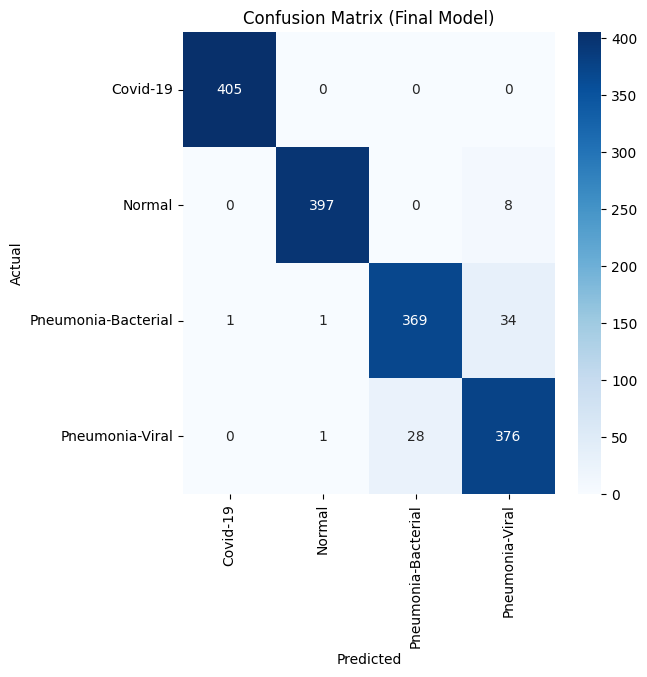

In [140]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final Model)")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
all_probs = []
all_labels = []

model_eff.eval()
model_inc.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = tta_predict(images, w1=0.7, w2=0.3,
                             boost=torch.tensor([1.0,1.0,1.1,1.1], device=device))

        all_probs.append(outputs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

In [ ]:
n_classes = len(class_names)

y_true = label_binarize(all_labels, classes=list(range(n_classes)))
y_score = all_probs

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [ ]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
macro_auc = np.mean(list(roc_auc.values()))
print("🔥 Macro AUC:", round(macro_auc, 4))

In [ ]:
import numpy as np
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    balanced_accuracy_score, cohen_kappa_score
)
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.utils import resample

In [ ]:
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print("Macro F1-score:", macro_f1)

In [ ]:
auc_roc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print("AUC-ROC:", auc_roc)

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

num_classes = cm.shape[0]

sensitivity_list = []
specificity_list = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)

    sensitivity_list.append(sensitivity)
    specificity_list.append(specificity)

print("Sensitivity (per class):", sensitivity_list)
print("Specificity (per class):", specificity_list)

print("Mean Sensitivity:", np.mean(sensitivity_list))
print("Mean Specificity:", np.mean(specificity_list))

In [ ]:
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
print("Balanced Accuracy:", balanced_acc)

In [ ]:
kappa = cohen_kappa_score(all_labels, all_preds)
print("Cohen’s Kappa:", kappa)

In [ ]:
def bootstrap_ci(y_true, y_pred, metric_func, n_iterations=1000):
    scores = []
    n = len(y_true)

    for _ in range(n_iterations):
        indices = resample(np.arange(n), replace=True)
        score = metric_func(y_true[indices], y_pred[indices])
        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return lower, upper

ci_lower, ci_upper = bootstrap_ci(
    np.array(all_labels),
    np.array(all_preds),
    lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro')
)

print(f"Macro F1 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

In [ ]:
# predictions from two models
preds_model1 = all_preds          # your model
preds_model2 = baseline_preds     # another model

correct1 = preds_model1 == all_labels
correct2 = preds_model2 == all_labels

# contingency table
table = [[0, 0],
         [0, 0]]

for i in range(len(all_labels)):
    if correct1[i] and correct2[i]:
        table[0][0] += 1
    elif correct1[i] and not correct2[i]:
        table[0][1] += 1
    elif not correct1[i] and correct2[i]:
        table[1][0] += 1
    else:
        table[1][1] += 1

result = mcnemar(table, exact=False, correction=True)

print("McNemar Test Statistic:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("Statistically significant difference")
else:
    print("No significant difference")

In [ ]:
!pip install torchcam

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

In [ ]:
target_layer = model_eff._blocks[-1]

In [ ]:
cam_extractor = GradCAM(model_eff, target_layer)
model_eff.eval()

In [ ]:
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0].item()

In [ ]:
out = model_eff(image)
pred_class = out.argmax(dim=1).item()

In [ ]:
activation_map = cam_extractor(pred_class, out)[0].cpu()

In [ ]:
img = image.squeeze().cpu()
img = (img - img.min()) / (img.max() - img.min())

result = overlay_mask(
    to_pil_image(img),
    to_pil_image(activation_map, mode='F'),
    alpha=0.5
)

plt.imshow(result)
plt.title(f"Grad-CAM | Pred: {class_names[pred_class]}")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import torch.nn.functional as F

In [ ]:
def generate_masks(N, s, p1):

    masks = np.random.rand(N, s, s) < p1
    masks = masks.astype(np.float32)

    masks = torch.tensor(masks).unsqueeze(1)  # (N,1,s,s)

    return masks

In [ ]:
def upscale_masks(masks, size):

    return F.interpolate(masks, size=size, mode='bilinear', align_corners=False)

In [ ]:
def rise_explain(model, image, target_class, N=1000, s=8, p1=0.5):

    model.eval()

    _, _, H, W = image.shape

    masks = generate_masks(N, s, p1).to(device)
    masks = upscale_masks(masks, (H, W))

    masked_images = image * masks

    preds = []

    with torch.no_grad():
        for i in range(N):
            out = model(masked_images[i].unsqueeze(0))
            prob = torch.softmax(out, dim=1)[0, target_class]
            preds.append(prob.item())

    preds = torch.tensor(preds).to(device)

    saliency = torch.sum(masks.squeeze(1) * preds.view(-1,1,1), dim=0)

    saliency = saliency / (N * p1)

    return saliency.cpu()

In [ ]:
saliency = rise_explain(model_eff, image, pred_class)

In [ ]:
plt.imshow(saliency, cmap='jet')
plt.title(f"RISE | Pred: {class_names[pred_class]}")
plt.axis('off')
plt.show()